## Code for plotting results of Ti/Tv ratio and nucleotide diversity from the variant matrix

#### Calculating Ti/Tv and nucleotide diversity for all samples 

In [1]:
# Import statements
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob

In [17]:
import pandas as pd
from pathlib import Path

base_dir = Path("/private/groups/patenlab/mira/centrolign/analysis/variant_matrix/default")

rows = []
for subgroup_dir in sorted(base_dir.iterdir()):
    subgroup = subgroup_dir.name
    result_file = subgroup_dir / f"{subgroup}.nucdiv_results.txt"
    if not result_file.exists():
        continue

    row = {"subgroup": subgroup}
    row["chr"] = subgroup.split("_")[0] if "_" in subgroup else subgroup

    with open(result_file) as f:
        content = f.read().strip()

    if not content:
        print(f"Warning: empty file for {subgroup}")
        continue

    try:
        for line in content.splitlines():
            key, val = line.split(": ", 1)
            try:
                row[key] = float(val)
            except ValueError:
                row[key] = val
    except Exception as e:
        print(f"Warning: error parsing {subgroup}: {e}")
        continue


    rows.append(row)

nucdiv_df = pd.DataFrame(rows)
nucdiv_df


,subgroup,chr,total aligned pairs,total nucleotide differences,nucleotide diversity,Ti/Tv ratio (differences),Ti/Tv ratio (events)
0,chr10_subgroupA,chr10,5.762468e+09,16719802.0,2.901500e-03,0.637090,0.633797
1,chr10_subgroupB,chr10,1.407178e+09,3410362.0,2.423548e-03,0.618428,0.619029
2,chr11_subgroupA,chr11,8.444261e+09,15935222.0,1.887107e-03,0.596911,0.576724
3,chr11_subgroupB,chr11,3.650184e+09,7448544.0,2.040594e-03,0.578115,0.565243
4,chr11_subgroupC,chr11,3.706399e+09,7400225.0,1.996608e-03,0.590842,0.577312
5,chr12_subgroup0,chr12,7.076922e+09,14015718.0,1.980482e-03,0.597299,0.574241
6,chr12_subgroup1,chr12,6.848903e+09,4889938.0,7.139739e-04,0.608389,0.598479
7,chr13_subgroup_0,chr13,2.649370e+09,3286783.0,1.240591e-03,0.750225,0.680683
8,chr13_subgroup_1,chr13,4.007779e+08,708914.0,1.768845e-03,0.662389,0.650092
9,chr14_subgroup_A,chr14,2.162057e+09,2758184.0,1.275722e-03,0.793804,0.733756


/data/tmp/ipykernel_632881/3212846486.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(chr_order))


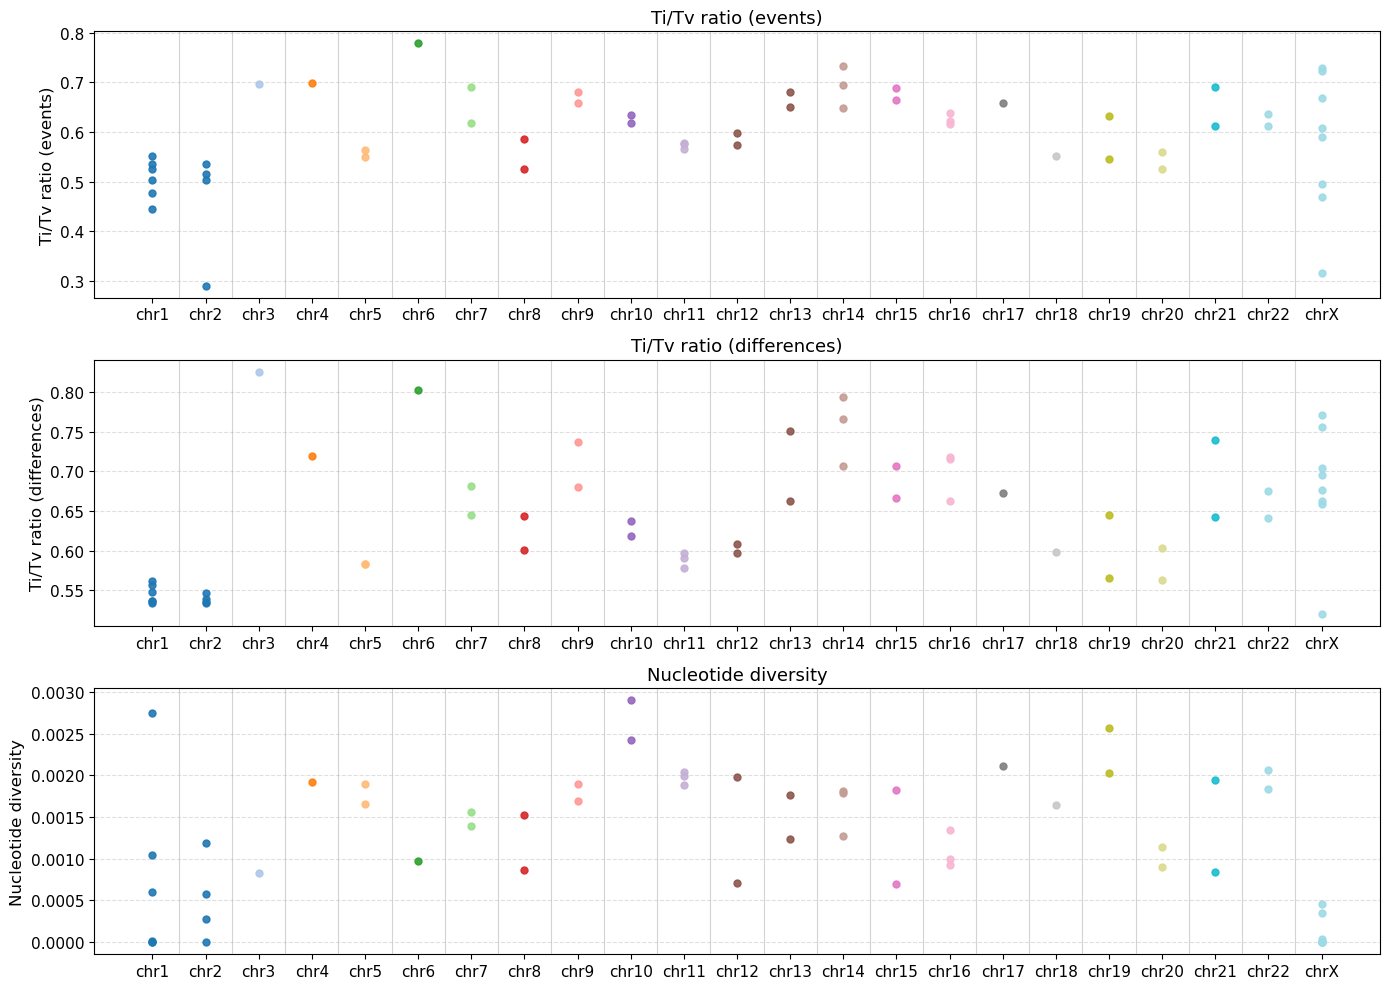

In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

nucdiv_plot = nucdiv_df[nucdiv_df["chr"] != "chrY"]

chr_order = sorted(nucdiv_plot["chr"].unique(),
                   key=lambda x: int(x.replace("chr", "")) if x.replace("chr", "").isdigit() else 100)

cmap = cm.get_cmap("tab20", len(chr_order))
chr_colors = {chr: cmap(i) for i, chr in enumerate(chr_order)}
x_positions = {chr: i for i, chr in enumerate(chr_order)}

metrics = [
    ("Ti/Tv ratio (events)",      "Ti/Tv ratio (events)"),
    ("Ti/Tv ratio (differences)", "Ti/Tv ratio (differences)"),
    ("nucleotide diversity",       "Nucleotide diversity"),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, (col, ylabel) in zip(axes, metrics):
    for _, row in nucdiv_plot.iterrows():
        x = x_positions[row["chr"]]
        ax.scatter(x, row[col], color=chr_colors[row["chr"]], s=25, alpha=0.9, zorder=3)

    # Vertical separators between chromosomes
    for i in range(len(chr_order) - 1):
        ax.axvline(i + 0.5, color='lightgrey', linewidth=0.8, zorder=1)

    ax.set_title(ylabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, axis='y', linestyle="--", alpha=0.4)
    ax.set_xticks(range(len(chr_order)))
    ax.set_xticklabels(chr_order, rotation=0, ha="center", fontsize=11)


plt.tight_layout()
plt.show()




In [19]:
## write out csv file 
nucdiv_df.to_csv("/private/groups/patenlab/mira/centrolign/analysis/variant_matrix/default/nucdiv_results.csv", index=False)

### For sample pairs only with dist < 0.2

In [ ]:
import pandas as pd
from pathlib import Path

base_dir = Path("/private/groups/patenlab/mira/centrolign/analysis/variant_matrix/pairs_lt_0.2")

rows = []
for subgroup_dir in sorted(base_dir.iterdir()):
    subgroup = subgroup_dir.name
    result_file = subgroup_dir / f"{subgroup}.nucdiv_results.txt"
    if not result_file.exists():
        continue

    row = {"subgroup": subgroup}
    row["chr"] = subgroup.split("_")[0] if "_" in subgroup else subgroup

    with open(result_file) as f:
        content = f.read().strip()

    if not content:
        print(f"Warning: empty file for {subgroup}")
        continue

    try:
        for line in content.splitlines():
            key, val = line.split(": ", 1)
            try:
                row[key] = float(val)
            except ValueError:
                row[key] = val
    except Exception as e:
        print(f"Warning: error parsing {subgroup}: {e}")
        continue


    rows.append(row)

nucdiv_df_2 = pd.DataFrame(rows)

,subgroup,chr,Pairs within distance threshold 0.2,Cigar files found,total aligned pairs,total nucleotide differences,nucleotide diversity,Ti/Tv ratio (differences),Ti/Tv ratio (events)
0,chr10_subgroupA,chr10,133.0,"90, missing: 43",206652237.0,72076.0,3.487792e-04,0.608911,0.614610
1,chr10_subgroupB,chr10,133.0,"43, missing: 90",78375465.0,19988.0,2.550288e-04,0.618068,0.617667
2,chr11_subgroupA,chr11,454.0,"285, missing: 169",746386791.0,281043.0,3.765380e-04,0.553857,0.553892
3,chr11_subgroupB,chr11,454.0,"51, missing: 403",215408624.0,65860.0,3.057445e-04,0.537205,0.537367
4,chr11_subgroupC,chr11,454.0,"118, missing: 336",361728085.0,130365.0,3.603950e-04,0.553981,0.550735
5,chr12_subgroup0,chr12,241.0,"77, missing: 164",189492771.0,55836.0,2.946603e-04,0.564165,0.558790
6,chr12_subgroup1,chr12,241.0,"164, missing: 77",402303156.0,131471.0,3.267958e-04,0.589542,0.591644
7,chr13_subgroup_0,chr13,134.0,"75, missing: 59",89915322.0,22024.0,2.449416e-04,0.636499,0.644486
8,chr13_subgroup_1,chr13,134.0,"59, missing: 75",71280933.0,20749.0,2.910877e-04,0.546125,0.587597
9,chr14_subgroup_A,chr14,230.0,"60, missing: 170",83925406.0,19745.0,2.352684e-04,0.685734,0.684539


/data/tmp/ipykernel_3119888/812368757.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(chr_order))


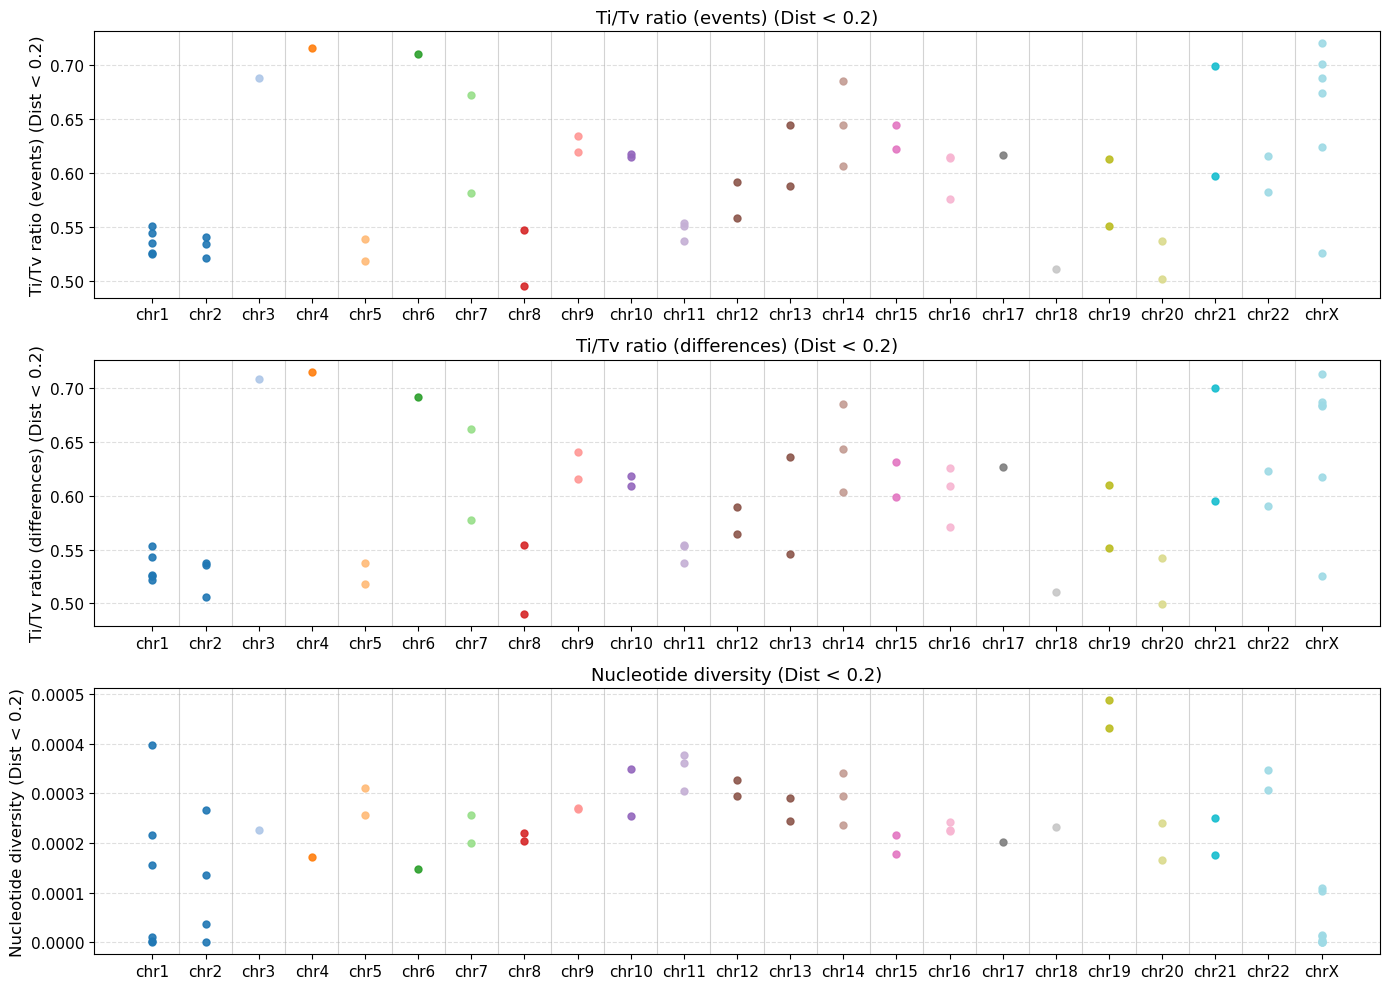

In [5]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

nucdiv_plot = nucdiv_df_2[nucdiv_df_2["chr"] != "chrY"]

chr_order = sorted(nucdiv_plot["chr"].unique(),
                   key=lambda x: int(x.replace("chr", "")) if x.replace("chr", "").isdigit() else 100)

cmap = cm.get_cmap("tab20", len(chr_order))
chr_colors = {chr: cmap(i) for i, chr in enumerate(chr_order)}
x_positions = {chr: i for i, chr in enumerate(chr_order)}

metrics = [
    ("Ti/Tv ratio (events)",      "Ti/Tv ratio (events) (Dist < 0.2)"),
    ("Ti/Tv ratio (differences)", "Ti/Tv ratio (differences) (Dist < 0.2)"),
    ("nucleotide diversity",       "Nucleotide diversity (Dist < 0.2)"),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, (col, ylabel) in zip(axes, metrics):
    for _, row in nucdiv_plot.iterrows():
        x = x_positions[row["chr"]]
        ax.scatter(x, row[col], color=chr_colors[row["chr"]], s=25, alpha=0.9, zorder=3)

    # Vertical separators between chromosomes
    for i in range(len(chr_order) - 1):
        ax.axvline(i + 0.5, color='lightgrey', linewidth=0.8, zorder=1)

    ax.set_title(ylabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, axis='y', linestyle="--", alpha=0.4)
    ax.set_xticks(range(len(chr_order)))
    ax.set_xticklabels(chr_order, rotation=0, ha="center", fontsize=11)


plt.tight_layout()
plt.show()



### For sample pairs with dist < 0.1

In [6]:
import pandas as pd
from pathlib import Path

base_dir = Path("/private/groups/patenlab/mira/centrolign/analysis/variant_matrix/pairs_lt_0.1")

rows = []
for subgroup_dir in sorted(base_dir.iterdir()):
    subgroup = subgroup_dir.name
    result_file = subgroup_dir / f"{subgroup}.nucdiv_results.txt"
    if not result_file.exists():
        continue

    row = {"subgroup": subgroup}
    row["chr"] = subgroup.split("_")[0] if "_" in subgroup else subgroup

    with open(result_file) as f:
        content = f.read().strip()

    if not content:
        print(f"Warning: empty file for {subgroup}")
        continue

    try:
        for line in content.splitlines():
            key, val = line.split(": ", 1)
            try:
                row[key] = float(val)
            except ValueError:
                row[key] = val
    except Exception as e:
        print(f"Warning: error parsing {subgroup}: {e}")
        continue


    rows.append(row)

nucdiv_df_1 = pd.DataFrame(rows)

/data/tmp/ipykernel_3119888/1906847130.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20", len(chr_order))


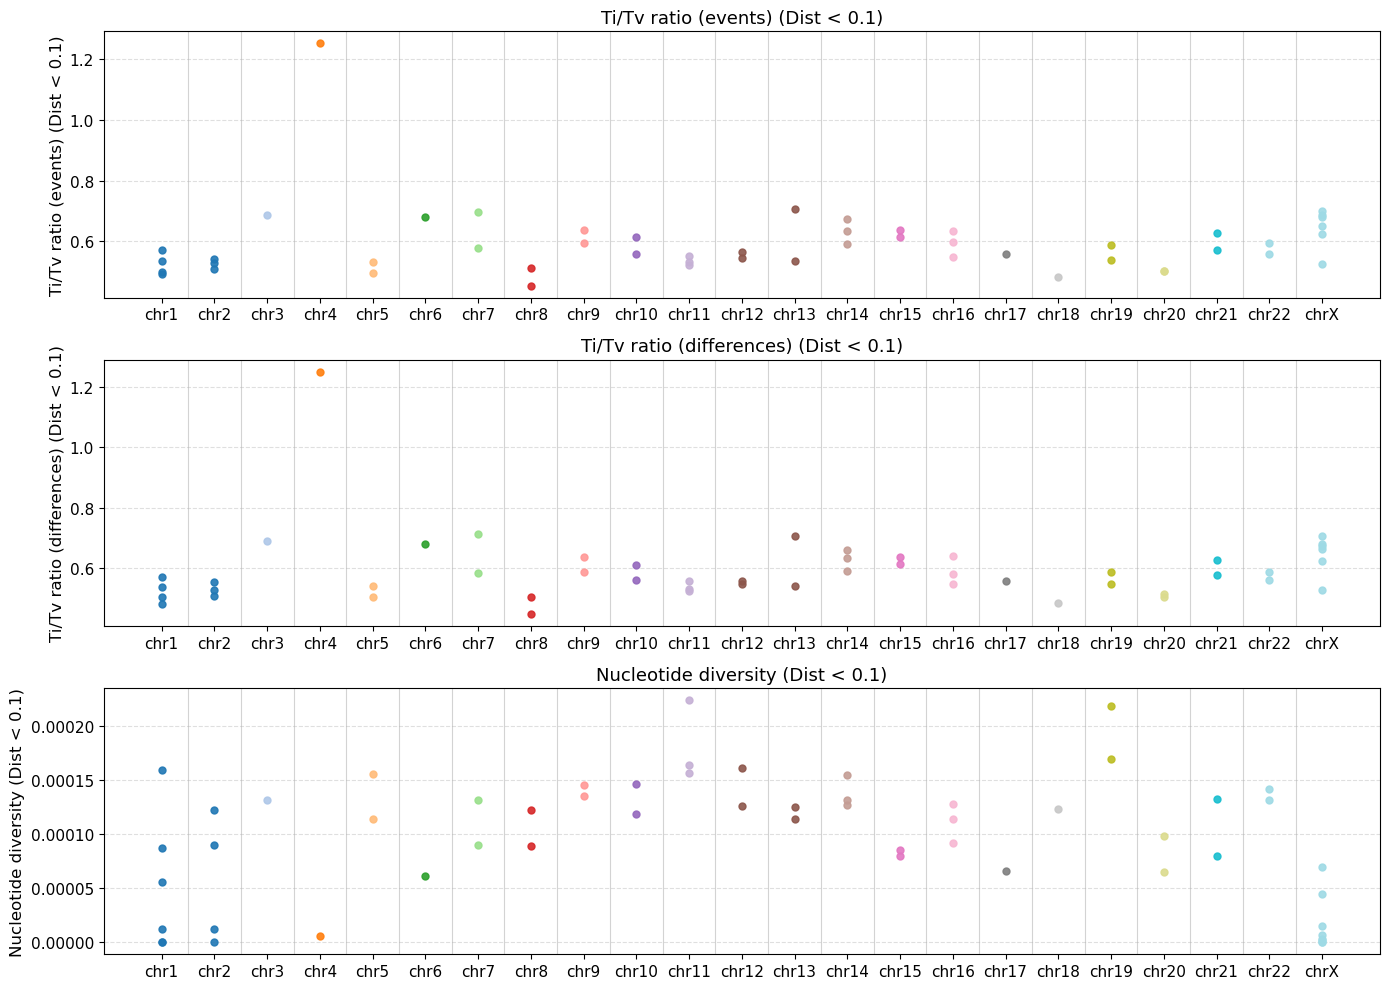

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

nucdiv_plot = nucdiv_df_1[nucdiv_df_1["chr"] != "chrY"]

chr_order = sorted(nucdiv_plot["chr"].unique(),
                   key=lambda x: int(x.replace("chr", "")) if x.replace("chr", "").isdigit() else 100)

cmap = cm.get_cmap("tab20", len(chr_order))
chr_colors = {chr: cmap(i) for i, chr in enumerate(chr_order)}
x_positions = {chr: i for i, chr in enumerate(chr_order)}

metrics = [
    ("Ti/Tv ratio (events)",      "Ti/Tv ratio (events) (Dist < 0.1)"),
    ("Ti/Tv ratio (differences)", "Ti/Tv ratio (differences) (Dist < 0.1)"),
    ("nucleotide diversity",       "Nucleotide diversity (Dist < 0.1)"),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, (col, ylabel) in zip(axes, metrics):
    for _, row in nucdiv_plot.iterrows():
        x = x_positions[row["chr"]]
        ax.scatter(x, row[col], color=chr_colors[row["chr"]], s=25, alpha=0.9, zorder=3)

    # Vertical separators between chromosomes
    for i in range(len(chr_order) - 1):
        ax.axvline(i + 0.5, color='lightgrey', linewidth=0.8, zorder=1)

    ax.set_title(ylabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, axis='y', linestyle="--", alpha=0.4)
    ax.set_xticks(range(len(chr_order)))
    ax.set_xticklabels(chr_order, rotation=0, ha="center", fontsize=11)


plt.tight_layout()
plt.show()
